In [85]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import datetime
from itertools import product

In [39]:
sales_train = pd.read_csv('../clean_data//sales_train.csv')
shops = pd.read_csv('../clean_data/shops.csv')
items = pd.read_csv('../clean_data/items.csv')
item_categories = pd.read_csv('../clean_data/item_categories.csv')


In [40]:
sales_train.info(show_counts=True)

<class 'pandas.DataFrame'>
RangeIndex: 2935838 entries, 0 to 2935837
Data columns (total 6 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   date            2935838 non-null  str    
 1   date_block_num  2935838 non-null  int64  
 2   shop_id         2935838 non-null  int64  
 3   item_id         2935838 non-null  int64  
 4   item_price      2935838 non-null  float64
 5   item_cnt_day    2935838 non-null  float64
dtypes: float64(2), int64(3), str(1)
memory usage: 134.4 MB


In [41]:
sales_train.sample(5)

,date,date_block_num,shop_id,item_id,item_price,item_cnt_day
1887301,19.08.2014,19,37,20949,5.0,3.0
801871,01.08.2013,7,22,12218,1600.0,1.0
1708485,25.06.2014,17,27,9844,217.5,1.0
1325221,18.01.2014,12,42,2830,649.0,1.0
805656,12.08.2013,7,28,15044,699.0,2.0


In [42]:
sales_train.describe().round(3).transpose()

,count,mean,std,min,25%,50%,75%,max
date_block_num,2935838.0,14.570,9.423,0.00,7.0,14.0,23.0,33.0
shop_id,2935838.0,33.002,16.227,0.00,22.0,31.0,47.0,59.0
item_id,2935838.0,10197.228,6324.293,0.00,4476.0,9343.0,15684.0,22169.0
item_price,2935838.0,890.730,1720.156,0.07,249.0,399.0,999.0,50999.0
item_cnt_day,2935838.0,1.244,2.216,0.00,1.0,1.0,1.0,669.0


In [43]:
items.info()

<class 'pandas.DataFrame'>
RangeIndex: 22170 entries, 0 to 22169
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   item_name         22170 non-null  str  
 1   item_id           22170 non-null  int64
 2   item_category_id  22170 non-null  int64
dtypes: int64(2), str(1)
memory usage: 519.7 KB


In [44]:
items.item_category_id.value_counts()

item_category_id
40    5035
55    2365
37    1780
31    1125
58     790
      ... 
1        2
50       2
10       1
51       1
79       1
Name: count, Length: 84, dtype: int64

### Наиболее часто встречающиеся Items

In [45]:
sales_train.item_id.value_counts()

item_id
20949    31339
5822      9408
17717     9067
2808      7479
4181      6853
         ...  
8428         1
7903         1
7610         1
7635         1
7640         1
Name: count, Length: 21806, dtype: int64

### Наиболее часто встречающиеся Магазины  

In [46]:
sales_train.shop_id.value_counts()

shop_id
31    235636
25    186103
54    143479
28    142234
57    117428
42    109252
27    105366
6      82663
58     71441
56     69573
46     66321
50     65171
19     63911
15     59511
35     58445
21     58132
7      58076
47     56695
26     53910
18     53227
24     53032
53     52921
16     52734
30     50860
29     49225
38     46013
22     45434
51     44433
52     43502
59     42108
41     41967
37     39638
44     39530
43     39282
4      38242
5      38179
14     36979
45     35891
55     34769
12     34690
2      25991
3      25532
17     22950
48     21612
10     21397
13     17824
49     15849
39     13440
0       9857
32      7946
23      6963
34      5752
1       5678
33      5027
40      4257
9       3751
8       3412
20      1792
11       499
36       306
Name: count, dtype: int64

In [47]:
train = sales_train.join(items, on='item_id', rsuffix='_').join(shops, on='shop_id', rsuffix='_').join(item_categories, on='item_category_id', rsuffix='_').drop(['item_id_', 'shop_id_', 'item_category_id_'], axis=1)

In [48]:
train.info(show_counts=True)

<class 'pandas.DataFrame'>
RangeIndex: 2935838 entries, 0 to 2935837
Data columns (total 10 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   date                2935838 non-null  str    
 1   date_block_num      2935838 non-null  int64  
 2   shop_id             2935838 non-null  int64  
 3   item_id             2935838 non-null  int64  
 4   item_price          2935838 non-null  float64
 5   item_cnt_day        2935838 non-null  float64
 6   item_name           2935838 non-null  str    
 7   item_category_id    2935838 non-null  int64  
 8   shop_name           2935838 non-null  str    
 9   item_category_name  2935838 non-null  str    
dtypes: float64(2), int64(4), str(4)
memory usage: 224.0 MB


In [49]:
train['date'] = pd.to_datetime(train['date'], dayfirst=True)

In [50]:
print("Начальная дата:" ,train['date'].min().date())
print("Конечная дата:" ,train['date'].max().date())

Начальная дата: 2013-01-01
Конечная дата: 2015-10-31


In [51]:
drop_features = ['shop_id', 'item_id', 'item_category_id']
str_features = ['item_name', 'shop_name', 'item_category_name']


In [63]:
train.info(show_counts=True)

<class 'pandas.DataFrame'>
RangeIndex: 2935838 entries, 0 to 2935837
Data columns (total 10 columns):
 #   Column              Non-Null Count    Dtype         
---  ------              --------------    -----         
 0   date                2935838 non-null  datetime64[us]
 1   date_block_num      2935838 non-null  int64         
 2   shop_id             2935838 non-null  int64         
 3   item_id             2935838 non-null  int64         
 4   item_price          2935838 non-null  float64       
 5   item_cnt_day        2935838 non-null  float64       
 6   item_name           2935838 non-null  str           
 7   item_category_id    2935838 non-null  int64         
 8   shop_name           2935838 non-null  str           
 9   item_category_name  2935838 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(4), str(3)
memory usage: 224.0 MB


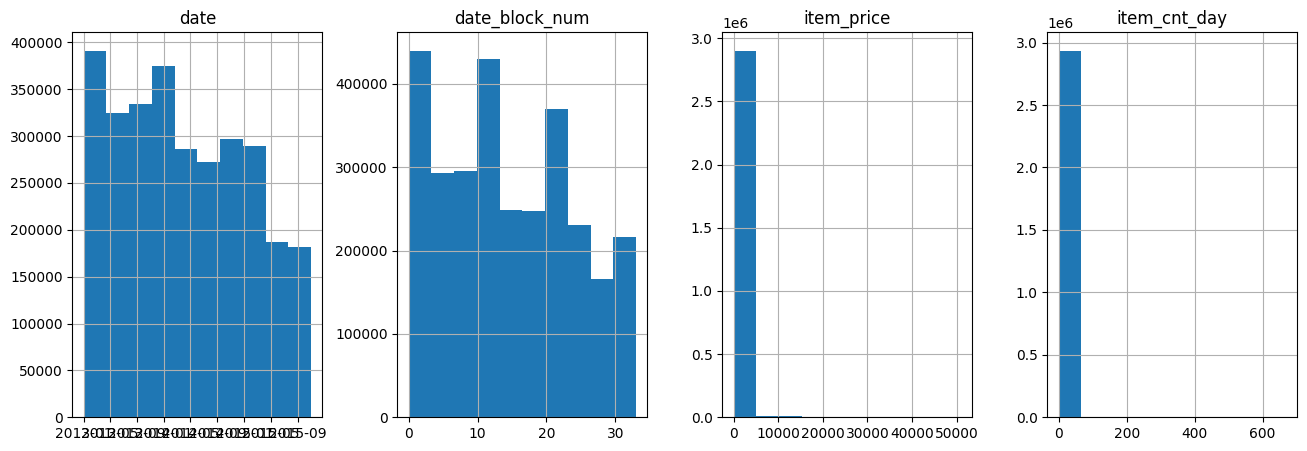

In [53]:
train.drop(drop_features, axis=1).hist(figsize=(20, 5), layout=(-1, 5));

In [58]:
numeric_train = train.drop([i for i in train.columns if i in str_features], axis=1)

In [59]:
numeric_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 2935838 entries, 0 to 2935837
Data columns (total 7 columns):
 #   Column            Dtype         
---  ------            -----         
 0   date              datetime64[us]
 1   date_block_num    int64         
 2   shop_id           int64         
 3   item_id           int64         
 4   item_price        float64       
 5   item_cnt_day      float64       
 6   item_category_id  int64         
dtypes: datetime64[us](1), float64(2), int64(4)
memory usage: 156.8 MB


In [84]:
monthly_sales = train.groupby(['date_block_num', 'shop_id', 'item_id' ,'item_category_id'], as_index=False).agg(
    item_sum_month=('item_cnt_day','sum'),
    transaction=('item_cnt_day', 'count'),
    item_mean_month=('item_cnt_day', 'mean'),
    item_price_month_sum=('item_price', 'sum'),
    item_price_month_mean=('item_price', 'mean')
)


In [86]:
shop_ids = train['shop_id'].unique()
item_ids = train['item_id'].unique()
month = range(34)

empty_df_list = list(product(month, shop_ids, item_ids))
empty_df = pd.DataFrame(empty_df_list, columns=['date_block_num', 'shop_id', 'item_id'])

In [88]:
train_monthly = pd.merge(empty_df, monthly_sales, on=['date_block_num','shop_id','item_id'], how='left')
train_monthly.fillna(0, inplace=True)

,date_block_num,shop_id,item_id,item_category_id,item_sum_month,transaction,item_mean_month,item_price_month_sum,item_price_month_mean
0,0,59,22154,37.0,1.0,1.0,1.0,999.0,999.0
1,0,59,2552,0.0,0.0,0.0,0.0,0.0,0.0
2,0,59,2554,0.0,0.0,0.0,0.0,0.0,0.0
3,0,59,2555,0.0,0.0,0.0,0.0,0.0,0.0
4,0,59,2564,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...
44484235,33,36,8428,0.0,0.0,0.0,0.0,0.0,0.0
44484236,33,36,7903,0.0,0.0,0.0,0.0,0.0,0.0
44484237,33,36,7610,0.0,0.0,0.0,0.0,0.0,0.0
44484238,33,36,7635,0.0,0.0,0.0,0.0,0.0,0.0


In [90]:
train_monthly['year'] = train_monthly['date_block_num'].apply(lambda x: ((x//12) + 2013))
train_monthly['month'] = train_monthly['date_block_num'].apply(lambda x: (x % 12))

In [92]:
train_monthly.info(show_counts=True)

<class 'pandas.DataFrame'>
RangeIndex: 44484240 entries, 0 to 44484239
Data columns (total 11 columns):
 #   Column                 Non-Null Count     Dtype  
---  ------                 --------------     -----  
 0   date_block_num         44484240 non-null  int64  
 1   shop_id                44484240 non-null  int64  
 2   item_id                44484240 non-null  int64  
 3   item_category_id       44484240 non-null  float64
 4   item_sum_month         44484240 non-null  float64
 5   transaction            44484240 non-null  float64
 6   item_mean_month        44484240 non-null  float64
 7   item_price_month_sum   44484240 non-null  float64
 8   item_price_month_mean  44484240 non-null  float64
 9   year                   44484240 non-null  int64  
 10  month                  44484240 non-null  int64  
dtypes: float64(6), int64(5)
memory usage: 3.6 GB


In [94]:
train_monthly.to_csv('../tmp/train_monthly.csv', index=False)

In [93]:
#будем групировать на разные таблички для eda удобного
# пересмотреть в первой части, не надо убирать отрицательные значения, оказывается это ВОЗВРАТЫ